   index Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0      0         P1   33       1              2            4             5   
1      1        P10   17       1              3            1             5   
2      2       P100   35       1              4            5             6   
3      3      P1000   37       1              7            7             7   
4      4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  ...  Fatigue  \
0                     4             3                     2  ...        3   
1                     3             4                     2  ...        1   
2                     5             5                     4  ...        8   
3                     7             6                     7  ...        4   
4                     7             7                     6  ...        3   

   Weight Loss  Shortness of Breath  Wheezing  Swallowing Difficulty

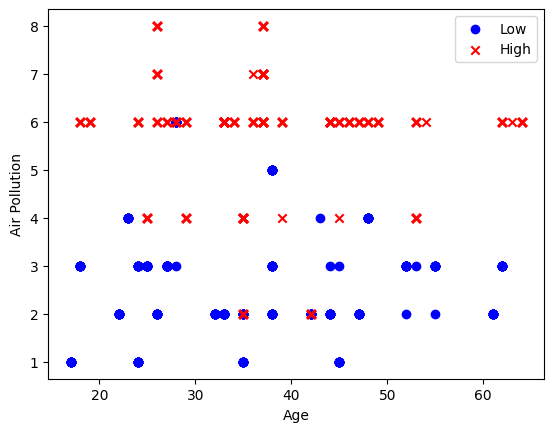

Accuracy = 50.898203592814376


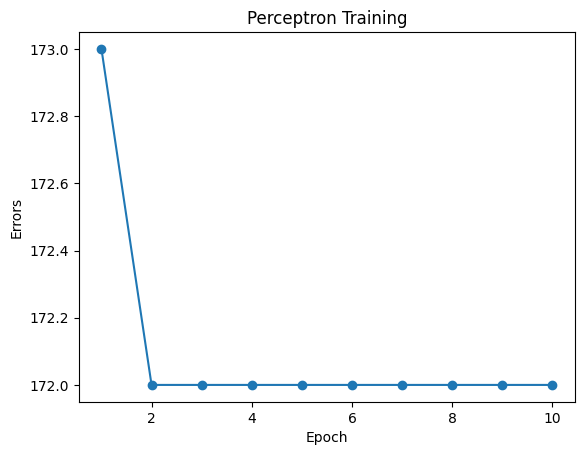

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ---------------- Perceptron Class ----------------
class Perceptron:
    def __init__(self, learning_rate=0.1):
        self.learning_rate = learning_rate
        self._b = 0.0
        self._w = None
        self.misclassified_samples = []

    def fit(self, x, y, n_iter=10):
        self._b = 0.0
        self._w = np.zeros(x.shape[1])
        self.misclassified_samples = []

        for _ in range(n_iter):
            errors = 0
            for xi, yi in zip(x, y):
                update = self.learning_rate * (yi - self.predict(xi))
                self._b += update
                self._w += update * xi
                errors += int(update != 0.0)

            self.misclassified_samples.append(errors)

    def f(self, x):
        return np.dot(x, self._w) + self._b

    def predict(self, x):
        return np.where(self.f(x) >= 0, 1, -1)

# ---------------- Load Dataset ----------------
df = pd.read_csv("/content/cancer patient data sets.csv")

print(df.head())

# Remove unwanted columns
df = df.drop(["index", "Patient Id"], axis=1)

# Keep only Low and High classes
df = df[df["Level"] != "Medium"]

# Target variable
y = df["Level"].values

# Select first two features (similar to Iris example)
x = df[["Age", "Air Pollution"]].values

# Plot the data
plt.scatter(x[y=="Low",0], x[y=="Low",1],
            color='blue', marker='o', label='Low')

plt.scatter(x[y=="High",0], x[y=="High",1],
            color='red', marker='x', label='High')

plt.xlabel("Age")
plt.ylabel("Air Pollution")
plt.legend()
plt.show()

# Convert labels into binary values
y = np.where(y == "Low", 1, -1)

# Feature Scaling
x[:,0] = (x[:,0] - x[:,0].mean()) / x[:,0].std()
x[:,1] = (x[:,1] - x[:,1].mean()) / x[:,1].std()

# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0
)

# Train Perceptron
classifier = Perceptron(learning_rate=0.01)
classifier.fit(x_train, y_train)

# Prediction Accuracy
pred = classifier.predict(x_test)

print("Accuracy =", accuracy_score(y_test, pred) * 100)

# Plot training errors
plt.plot(range(1, len(classifier.misclassified_samples)+1),
         classifier.misclassified_samples,
         marker='o')

plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.title("Perceptron Training")
plt.show()